In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

In [ ]:
n = 300

stock_a = np.cumsum(
    np.random.normal(
        0,
        1,
        n
    )
) + 100

noise = np.random.normal(
    0,
    2,
    n
)

stock_b = stock_a + noise

df = pd.DataFrame({
    'A': stock_a,
    'B': stock_b
})

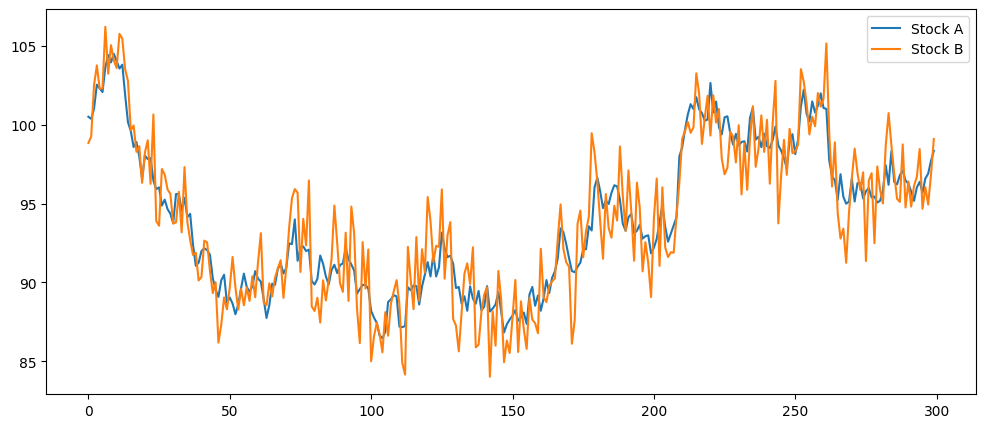

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(df['A'], label='Stock A')
plt.plot(df['B'], label='Stock B')

plt.legend()

plt.show()

In [ ]:
df['Spread'] = (
    df['A']
    - df['B']
)

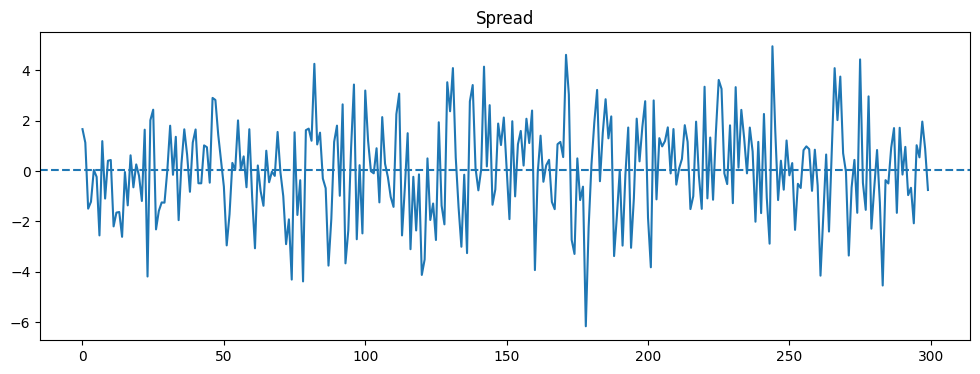

In [ ]:
plt.figure(figsize=(12,4))

plt.plot(df['Spread'])

plt.axhline(
    y=df['Spread'].mean(),
    linestyle='--'
)

plt.title("Spread")

plt.show()

In [ ]:
window = 20

df['SpreadMean'] = (
    df['Spread']
    .rolling(window)
    .mean()
)

df['SpreadStd'] = (
    df['Spread']
    .rolling(window)
    .std()
)

In [ ]:
df['SpreadZ'] = (
    (
        df['Spread']
        - df['SpreadMean']
    )
    /
    df['SpreadStd']
)

In [ ]:
df['Signal'] = 0

df.loc[
    df['SpreadZ'] > 2,
    'Signal'
] = -1

df.loc[
    df['SpreadZ'] < -2,
    'Signal'
] = 1

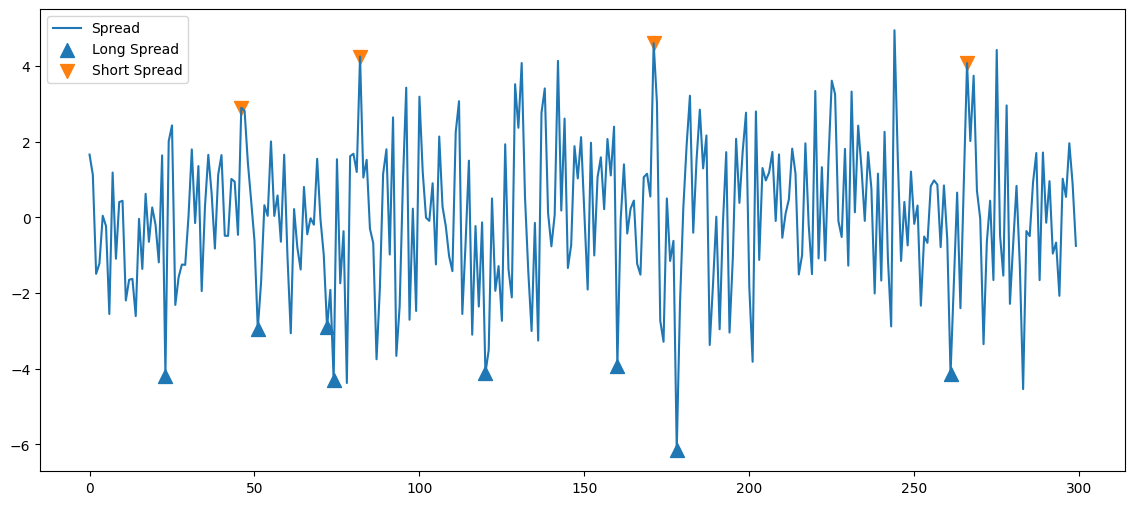

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    df['Spread'],
    label='Spread'
)

plt.scatter(
    df.index[df['Signal']==1],
    df['Spread'][df['Signal']==1],
    marker='^',
    s=100,
    label='Long Spread'
)

plt.scatter(
    df.index[df['Signal']==-1],
    df['Spread'][df['Signal']==-1],
    marker='v',
    s=100,
    label='Short Spread'
)

plt.legend()

plt.show()